# Nesting a Regional Ocean Model — Caribbean Sea Example

This notebook demonstrates MOM6-in-CESM **domain nesting**: running progressively finer child domains whose open-boundary conditions (OBCs) come from the next coarser parent, rather than from a global reanalysis like GLORYS.

Nesting lets you zoom into a turbulent feature (here: the **Caribbean Current** near 14°N, 72°W) at a fraction of the cost of running the full coarse domain at high resolution.

---

## Domain hierarchy

```
Parent       (carib12)     1/12°   -98.5→-35.5 lon, -6→32 lat
│
└── Middle child           1/24°   -76→-65 lon,  10→18 lat
    │
    └── Tiny child         1/48°   -73→-69 lon,  12→16 lat   ← smallest, highest res
```

**Rule of thumb**: each child should be no more than 4× finer than its parent (4:1 ratio).  
Here: 1/12° → 1/24° = 2× refinement; 1/24° → 1/48° = 2× refinement — both well within the safe range.

---

## Workflow

1. **Set up the parent** (carib12) — load existing grid/topo from a reference case, add middle-child nesting diagnostics to the `diag_table`, run for one month
2. **Load parent nesting output** — use `CESM_MOM_OUTPUT.get_mom6_output_data()` to read parent output
3. **Set up the middle child** — create grid/topo/vgrid, configure OBCs from parent output, add tiny-child nesting diagnostics to the middle child's `diag_table`
4. **Load middle-child nesting output** — read output files from the middle child run
5. **Set up the tiny child** — create grid/topo/vgrid, configure OBCs from middle-child output

---
# PART 1 — Parent Domain (carib12)

The parent is a 1/12° Caribbean + western Atlantic domain.  
Rather than regenerating the grid and bathymetry from scratch, we load them directly  
from the reference case files using `Grid.from_supergrid()` and `Topo.from_topo_file()`.

In [ ]:
from pathlib import Path
from CrocoDash.grid import Grid
from CrocoDash.topo import Topo
from CrocoDash.vgrid import VGrid
from CrocoDash.case import Case
from CrocoDash.raw_data_access.registry import ProductRegistry
from CrocoDash.raw_data_access.datasets.cesm_ocean_output import CESM_MOM_OUTPUT

ProductRegistry.load()

## Step 1.1 — Paths and reference files

In [2]:
CESMROOT     = Path("~/work/installs/CROCESM_workshop_2025").expanduser()
PARENT_CASE  = Path("~/croc_cases/carib12_nesting_demo").expanduser()
PARENT_INPUT = Path("/glade/u/home/manishrv/scratch/croc_input/carib12_nesting_demo")
PROJECT      = "ncgd0011"

# Reference case files from Ajanney's carib12 run
REF_INPUT     = Path("/glade/work/ajanney/CrocoDash_Input/carib12_credit_tides_runoff_02/ocnice")
REF_SUPERGRID = REF_INPUT / "ocean_hgrid_carib_012_hgrid_df37c4.nc"
REF_TOPOG     = REF_INPUT / "ocean_topog_carib_012_hgrid_df37c4.nc"
REF_VGRID     = REF_INPUT / "vgrid_65L_20200626.nc"

## Step 1.2 — Load parent grid, topo, and vgrid from reference files

In [4]:
# Load the existing carib12 supergrid directly — no need to re-generate
parent_grid = Grid.from_supergrid(REF_SUPERGRID, name="carib12_nesting_demo")

# Load the existing topography — uses the same grid hash so they match
parent_topo = Topo.from_topo_file(
    grid           = parent_grid,
    topo_file_path = REF_TOPOG,
    min_depth      = 10.0,
    varname        = "depth",
    git            = False,
)

# Load the existing 65-level vertical grid
parent_vgrid = VGrid.from_file(str(REF_VGRID))

print(f"Parent grid: {parent_grid}")
print(f"Parent topo depth range: {float(parent_topo.depth.min()):.1f} – {float(parent_topo.depth.max()):.1f} m")

Parent grid: <mom6_forge.grid.Grid object at 0x7f746da64490>
Parent topo depth range: 0.0 – 8318.5 m


## Step 1.3 — Create the CESM case

In [5]:
parent_case = Case(
    cesmroot      = CESMROOT,
    caseroot      = PARENT_CASE,
    inputdir      = PARENT_INPUT,
    compset       = "1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV",
    ocn_grid      = parent_grid,
    ocn_topo      = parent_topo,
    ocn_vgrid     = parent_vgrid,
    machine       = "derecho",
    project       = PROJECT,
    override      = True,
)

INFO:	initialize:Initializing the visualCaseGen system...
INFO:  csp_solver:CspSolver initialized.


Creating case...

• Updating ccs_config/modelgrid_aliases_nuopc.xml file to include the new resolution "carib12_nesting_demo" consisting of the following component grids.
 atm grid: "TL319" 
 lnd grid: "TL319" 
 ocn grid: "carib12_nesting_demo".
 rof grid: "null".

• Updating ccs_config/component_grids_nuopc.xml file to include newly generated ocean grid "carib12_nesting_demo" with the following properties:
 nx: 759, ny: 457. ocean mesh: /glade/u/home/manishrv/scratch/croc_input/carib12_nesting_demo/ocnice/ESMF_mesh_carib12_nesting_demo_16427a.nc.

Running the create_newcase tool with the following command:

/glade/u/home/manishrv/work/installs/CROCESM_workshop_2025/cime/scripts/create_newcase --compset 1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV --res carib12_nesting_demo --case /glade/u/home/manishrv/croc_cases/carib12_nesting_demo --machine derecho --run-unsupported --project ncgd0011 --non-local 

The create_newcase command was successful.

Navigating to the case directory

INFO:	stage:SUCCESS: All stages are complete.


Case created successfully at /glade/u/home/manishrv/croc_cases/carib12_nesting_demo.

To further customize, build, and run the case, navigate to the case directory in your terminal. To create another case, restart the notebook.

./xmlchange MOM6_MEMORY_MODE=dynamic_symmetric --non-local



## Step 1.5 — Configure parent forcings (reuse Ajanney's OBC files)

In [6]:
PARENT_DATES = ["2000-01-01 00:00:00", "2000-02-01 00:00:00"]

parent_case.configure_forcings(date_range=PARENT_DATES)

INFO:CrocoDash.forcing_configurations.base:[SKIP] tides missing args: ['tpxo_elevation_filepath', 'tpxo_velocity_filepath', 'tidal_constituents']
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGC incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] CICE incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGCIC incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGCIronForcing incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGCRiverNutrients incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] Runoff incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] Chl missing args: ['chl_processed_filepath']


Adding parameter changes to user_nl_mom:

  ! Initial conditions
  INIT_LAYERS_FROM_Z_FILE = True
  Z_INIT_ALE_REMAPPING = True
  TEMP_SALT_INIT_VERTICAL_REMAP_ONLY = True
  DEPRESS_INITIAL_SURFACE = True
  VELOCITY_CONFIG = file
  TEMP_SALT_Z_INIT_FILE = init_tracers.nc
  SURFACE_HEIGHT_IC_FILE = init_eta.nc
  VELOCITY_FILE = init_vel.nc
  Z_INIT_FILE_PTEMP_VAR = temp
  Z_INIT_FILE_SALT_VAR = salt
  SURFACE_HEIGHT_IC_VAR = eta_t
  U_IC_VAR = u
  V_IC_VAR = v

  ! Open boundary conditions
  OBC_NUMBER_OF_SEGMENTS = 4
  OBC_FREESLIP_VORTICITY = False
  OBC_FREESLIP_STRAIN = False
  OBC_COMPUTED_VORTICITY = True
  OBC_COMPUTED_STRAIN = True
  OBC_ZERO_BIHARMONIC = True
  OBC_TRACER_RESERVOIR_LENGTH_SCALE_OUT = 3.0E+04
  OBC_TRACER_RESERVOIR_LENGTH_SCALE_IN = 3000.0
  BRUSHCUTTER_MODE = True
  OBC_SEGMENT_001 = "J=0,I=0:N,FLATHER,ORLANSKI,NUDGED,ORLANSKI_TAN,NUDGED_TAN"
  OBC_SEGMENT_001_VELOCITY_NUDGING_TIMESCALES = 0.3, 360.0
  OBC_SEGMENT_001_DATA = "U=file:forcing_obc_segment_001.nc(u

In [ ]:
import shutil

# Reuse Ajanney's pre-processed OBC segments (2000–2020 daily data)
for seg in ["001", "002"]:
    src = REF_INPUT / f"forcing_obc_segment_{seg}.nc"
    dst = PARENT_INPUT /"ocnice" / f"forcing_obc_segment_{seg}.nc"
    if not dst.exists():
        print(f"Copying segment {seg} from reference case...")
        shutil.copy2(src, dst)
    else:
        print(f"Segment {seg} already present, skipping.")

# Skip process_forcings() — files already exist from reference case

Copying segment 001 from reference case...
Copying segment 002 from reference case...


---
# PART 3 — Middle Child Domain (1/24°)

The middle child covers the **eastern Caribbean** (-76→-65 lon, 10→18 lat) at **1/24°** resolution.  
Its open boundaries are driven by parent nesting slices.  
It also outputs its own nesting diagnostics so the tiny child can use its output as OBCs.

## Step 3.1 — Middle child horizontal grid

In [9]:
MID_CASE  = Path("~/croc_cases/carib_mid_child").expanduser()
MID_INPUT = Path("/glade/u/home/manishrv/scratch/croc_input/carib_mid_child")

# 1/24° — 2× refinement over the 1/12° parent
mid_grid = Grid(
    resolution = 1/24,
    xstart     = -76.0,
    lenx       = 11.0,   # -76 → -65
    ystart     = 10.0,
    leny       = 8.0,    # 10 → 18
    name       = "carib_mid_child",
)
mid_grid

## Step 3.2 — Middle child bathymetry

**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_from_dataset()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[topo_object_name].tidy_dataset() after regridding with mpi.
Slicing source bathymetry to domain: (-76.0, -65.0) x (10.0, 18.0) with buffer 0.5
Begin regridding dataset...

Original dataset size: 12.48 Mb
Regridded size: 1.62 Mb

Generating regridding weights using xESMF with method 'bilinear'...
Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... 

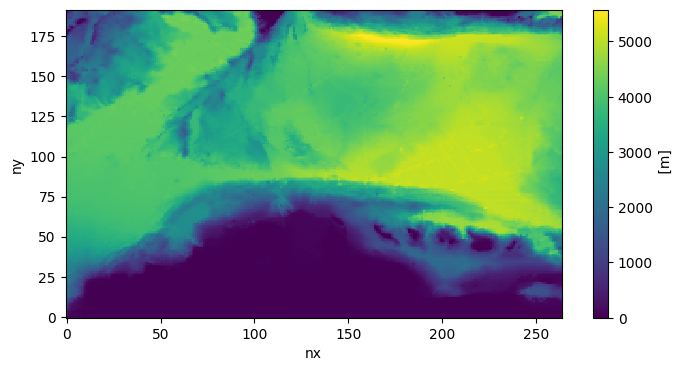

In [10]:
GEBCO = Path("/glade/derecho/scratch/manishrv/ice/croc/gebco/GEBCO_2024.nc")

mid_topo = Topo(grid=mid_grid, min_depth=10.0)
mid_topo.set_from_dataset(
    bathymetry_path           = GEBCO,
    longitude_coordinate_name = "lon",
    latitude_coordinate_name  = "lat",
    vertical_coordinate_name  = "elevation",
)
mid_topo.depth.plot(figsize=(8, 4))

## Step 3.3 — Middle child vertical grid (40 levels)

In [11]:
mid_vgrid = VGrid.hyperbolic(
    nk    = 40,
    depth = float(mid_topo.depth.max()),
    ratio = 10.0,
)

## Step 3.4 — Create the middle child CESM case

In [12]:
mid_case = Case(
    cesmroot      = CESMROOT,
    caseroot      = MID_CASE,
    inputdir      = MID_INPUT,
    compset       = "1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV",
    ocn_grid      = mid_grid,
    ocn_topo      = mid_topo,
    ocn_vgrid     = mid_vgrid,
    machine       = "derecho",
    project       = PROJECT,
    override      = True,
)

INFO:	initialize:Initializing the visualCaseGen system...
INFO:  csp_solver:CspSolver initialized.


Creating case...

• Updating ccs_config/modelgrid_aliases_nuopc.xml file to include the new resolution "carib_mid_child" consisting of the following component grids.
 atm grid: "TL319" 
 lnd grid: "TL319" 
 ocn grid: "carib_mid_child".
 rof grid: "null".

• Updating ccs_config/component_grids_nuopc.xml file to include newly generated ocean grid "carib_mid_child" with the following properties:
 nx: 264, ny: 192. ocean mesh: /glade/u/home/manishrv/scratch/croc_input/carib_mid_child/ocnice/ESMF_mesh_carib_mid_child_be3f1a.nc.

Running the create_newcase tool with the following command:

/glade/u/home/manishrv/work/installs/CROCESM_workshop_2025/cime/scripts/create_newcase --compset 1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV --res carib_mid_child --case /glade/u/home/manishrv/croc_cases/carib_mid_child --machine derecho --run-unsupported --project ncgd0011 --non-local 

The create_newcase command was successful.

Navigating to the case directory:

cd /glade/u/home/manishrv/croc_c

INFO:	stage:SUCCESS: All stages are complete.


Case created successfully at /glade/u/home/manishrv/croc_cases/carib_mid_child.

To further customize, build, and run the case, navigate to the case directory in your terminal. To create another case, restart the notebook.

./xmlchange MOM6_MEMORY_MODE=dynamic_symmetric --non-local



## Step 3.6 — Configure OBCs from parent nesting slices

> **Note**: `CESM_MOM_OUTPUT` (`CrocoDash/raw_data_access/datasets/cesm_ocean_output.py`)
> is a dedicated product for native MOM6 output, with MOM6-native variable/coordinate
> metadata (`thetao`/`so`/`uo`/`vo`/`zos` on `xh`/`yh`/`xq`/`yq`/`z_l`) — split out from
> the CESM-POP-oriented `CESM_POP_OUTPUT` product so the two don't share a mismatched
> metadata set. It has two access methods: `get_mom6_output_data` (multi-variable-per-
> file history/diag_table output) and `get_mom6_single_variable_data` (if the parent
> run's output is instead organized in the CESM single-variable-per-file/tseries
> convention). `CESM_MOM_OUTPUT` has no universal default `dataset_path` (it's meant to
> point at any user-supplied directory), so `configure_forcings()`'s automatic pipeline
> still needs that path threaded through per-call — the call below shows the intended
> interface; see the access methods' docstrings for direct-call usage that works today.

In [ ]:
MID_DATES = ["2000-01-01 00:00:00", "2000-02-01 00:00:00"]
mid_case.configure_forcings(
    date_range    = MID_DATES,
    product_name  = "cesm_mom_output",
    function_name = "get_mom6_output_data",
)


In [ ]:
mid_case.process_forcings()

---
# PART 5 — Tiny Child Domain (1/48°)

The tiny child covers a compact 4°×4° patch of the **southern Caribbean** (-73→-69 lon, 12→16 lat)  
at **1/48°** resolution — the finest level of the three-domain hierarchy.  
Its open boundaries come entirely from the middle child's nesting slice output.

## Step 5.1 — Tiny child horizontal grid

In [15]:
TINY_CASE  = Path("~/croc_cases/carib_tiny_child").expanduser()
TINY_INPUT = Path("/glade/u/home/manishrv/scratch/croc_input/carib_tiny_child")

# 1/48° — 2× refinement over the 1/24° middle child (192×192 grid points)
tiny_grid = Grid(
    resolution = 1/48,
    xstart     = -73.0,
    lenx       = 4.0,    # -73 → -69
    ystart     = 12.0,
    leny       = 4.0,    # 12 → 16
    name       = "carib_tiny_child",
)
tiny_grid

## Step 5.2 — Tiny child bathymetry

**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_from_dataset()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[topo_object_name].tidy_dataset() after regridding with mpi.
Slicing source bathymetry to domain: (-73.0, -69.0) x (12.0, 16.0) with buffer 0.5
Begin regridding dataset...

Original dataset size: 2.90 Mb
Regridded size: 1.18 Mb

Generating regridding weights using xESMF with method 'bilinear'...
Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... 

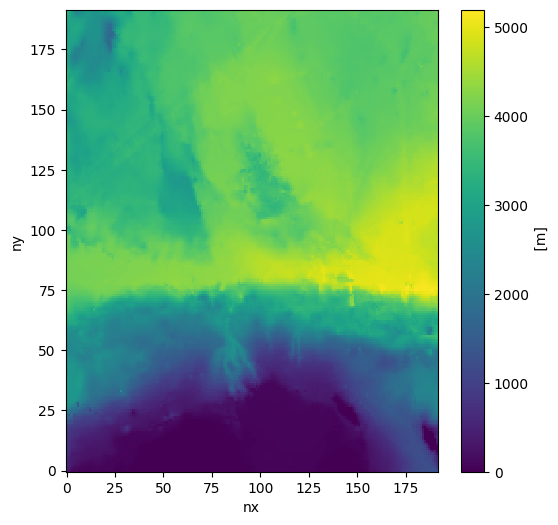

In [16]:
tiny_topo = Topo(grid=tiny_grid, min_depth=10.0)
tiny_topo.set_from_dataset(
    bathymetry_path           = GEBCO,
    longitude_coordinate_name = "lon",
    latitude_coordinate_name  = "lat",
    vertical_coordinate_name  = "elevation",
)
tiny_topo.depth.plot(figsize=(6, 6))

## Step 5.3 — Tiny child vertical grid (30 levels)

In [17]:
tiny_vgrid = VGrid.hyperbolic(
    nk    = 30,
    depth = float(tiny_topo.depth.max()),
    ratio = 10.0,
)

## Step 5.4 — Create the tiny child CESM case

In [18]:
tiny_case = Case(
    cesmroot      = CESMROOT,
    caseroot      = TINY_CASE,
    inputdir      = TINY_INPUT,
    compset       = "1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV",
    ocn_grid      = tiny_grid,
    ocn_topo      = tiny_topo,
    ocn_vgrid     = tiny_vgrid,
    machine       = "derecho",
    project       = PROJECT,
    override      = True,
)

INFO:	initialize:Initializing the visualCaseGen system...
INFO:  csp_solver:CspSolver initialized.


Creating case...

• Updating ccs_config/modelgrid_aliases_nuopc.xml file to include the new resolution "carib_tiny_child" consisting of the following component grids.
 atm grid: "TL319" 
 lnd grid: "TL319" 
 ocn grid: "carib_tiny_child".
 rof grid: "null".

• Updating ccs_config/component_grids_nuopc.xml file to include newly generated ocean grid "carib_tiny_child" with the following properties:
 nx: 192, ny: 192. ocean mesh: /glade/u/home/manishrv/scratch/croc_input/carib_tiny_child/ocnice/ESMF_mesh_carib_tiny_child_ebefb1.nc.

Running the create_newcase tool with the following command:

/glade/u/home/manishrv/work/installs/CROCESM_workshop_2025/cime/scripts/create_newcase --compset 1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV --res carib_tiny_child --case /glade/u/home/manishrv/croc_cases/carib_tiny_child --machine derecho --run-unsupported --project ncgd0011 --non-local 

The create_newcase command was successful.

Navigating to the case directory:

cd /glade/u/home/manishrv

INFO:	stage:SUCCESS: All stages are complete.


Case created successfully at /glade/u/home/manishrv/croc_cases/carib_tiny_child.

To further customize, build, and run the case, navigate to the case directory in your terminal. To create another case, restart the notebook.

./xmlchange MOM6_MEMORY_MODE=dynamic_symmetric --non-local



## Step 5.5 — Configure OBCs from middle-child nesting slices

> **Note**: same caveat as Step 3.6 — `CESM_MOM_OUTPUT.get_mom6_output_data` is the
> correct reader for the middle child's native MOM6 output, but `configure_forcings()`'s
> automatic pipeline still needs `dataset_path` threaded through per-call, so this call
> shows the intended interface rather than a fully working end-to-end path today.


In [ ]:
TINY_DATES = ["2000-01-01 00:00:00", "2000-02-01 00:00:00"]
tiny_case.configure_forcings(
    date_range    = TINY_DATES,
    product_name  = "cesm_mom_output",
    function_name = "get_mom6_output_data",
)
tiny_case.process_forcings()

---
## Summary

This notebook walked through a full 3-level nesting hierarchy:

| Domain | Resolution | lon | lat | OBC source |
|--------|-----------|-----|-----|------------|
| Parent (carib12) | 1/12° | -98.5→-35.5 | -6→32 | GLORYS / Ajanney OBC files |
| Middle child | 1/24° | -76→-65 | 10→18 | Parent nesting output |
| Tiny child | 1/48° | -73→-69 | 12→16 | Middle-child nesting output |

Each level runs independently. Once the parent finishes, the middle child can start;  
once the middle child finishes, the tiny child can start.

See `CESM_MOM_OUTPUT` (`CrocoDash/raw_data_access/datasets/cesm_ocean_output.py`) for the
native-MOM6-output readers used above — `get_mom6_output_data` (multi-variable-per-file
history/diag_table output) and `get_mom6_single_variable_data` (CESM tseries-style
output) — and their docstrings for direct-call usage. `CESM_MOM_OUTPUT` is a separate
product from `CESM_POP_OUTPUT` specifically because they need different variable/
coordinate metadata (native MOM6 names vs. CESM-POP names); full automatic integration
with `configure_forcings()`/`process_forcings()` still needs `dataset_path` threaded
through per-call rather than sourced from class-level metadata.